# Nonlinear Filtering: Extended vs. Unscented Kalman Filter

## Problem

The Kalman filter's exactness relies entirely on linear dynamics and linear observations —
neither of which holds for a bearings/range sensor, whose observation function
$h(x)=(\sqrt{p_x^2+p_y^2},\ \mathrm{atan2}(p_y,p_x))$ is genuinely nonlinear in the state. Two
standard extensions handle this: the **Extended Kalman Filter (EKF)**, which linearizes $h$ at the
current estimate via its Jacobian and reuses the linear-Gaussian machinery, and the **Unscented
Kalman Filter (UKF)**, which instead propagates a small deterministic set of points through the
*exact* nonlinear $h$ and reconstructs the mean/covariance from their images. This notebook derives
both, then runs them on identical noisy range-bearing data to measure which one actually tracks
better — not assumed in advance.

## Method

**EKF.** With nonlinear dynamics $x_k=f(x_{k-1})+w_k$ and nonlinear observation $y_k=h(x_k)+v_k$,
the EKF keeps the KF's predict/update *structure* (`kalman_filter.ipynb` in this folder) but
replaces $F,H$ with the Jacobians evaluated at the current estimate,
$$
F_k = \left.\frac{\partial f}{\partial x}\right|_{\hat x_{k-1}},\qquad
H_k = \left.\frac{\partial h}{\partial x}\right|_{\hat x_k^-},
$$
and replaces the linear predictions $F\hat x_{k-1}$, $H\hat x_k^-$ with the exact nonlinear
evaluations $f(\hat x_{k-1})$, $h(\hat x_k^-)$ — only the *covariance* propagation is linearized,
via $P_k^-=F_kP_{k-1}F_k^\top+Q$ and $S_k=H_kP_k^-H_k^\top+R$. This is a first-order Taylor
approximation of $f,h$ around the current estimate: accurate when the posterior's spread is small
relative to the scale on which $f,h$ curve, and increasingly poor otherwise.

**UKF, derived from the unscented transform.** Rather than linearizing $h$, the UKF propagates a
deterministic set of $2n+1$ **sigma points** — chosen so their sample mean and covariance match
$(\hat x,P)$ *exactly* — through the true nonlinear function, then reconstructs the output
mean/covariance from the transformed points' own weighted sample statistics:
$$
\chi_0=\hat x,\qquad \chi_i=\hat x+\big(\sqrt{(n+\lambda)P}\big)_i,\qquad
\chi_{n+i}=\hat x-\big(\sqrt{(n+\lambda)P}\big)_i,\quad i=1,\dots,n,
$$
with $\sqrt{(n+\lambda)P}$ a Cholesky factor's columns and $\lambda=\alpha^2(n+\kappa)-n$ a scaling
parameter. Weights $W_0^{(m)}=\lambda/(n+\lambda)$, $W_0^{(c)}=W_0^{(m)}+(1-\alpha^2+\beta)$,
$W_i^{(m)}=W_i^{(c)}=1/(2(n+\lambda))$ for $i\ge1$ are constructed so that
$\hat x=\sum_iW_i^{(m)}\chi_i$ and $P=\sum_iW_i^{(c)}(\chi_i-\hat x)(\chi_i-\hat x)^\top$ hold
exactly for the *untransformed* points by construction. Propagating each $\chi_i$ through $h$ to
get $\mathcal Y_i=h(\chi_i)$ and taking the same weighted statistics,
$$
\hat y=\sum_iW_i^{(m)}\mathcal Y_i,\quad
P_{yy}=\sum_iW_i^{(c)}(\mathcal Y_i-\hat y)(\mathcal Y_i-\hat y)^\top+R,\quad
P_{xy}=\sum_iW_i^{(c)}(\chi_i-\hat x)(\mathcal Y_i-\hat y)^\top,
$$
gives an estimate of $\mathbb E[h(x)]$ and $\mathrm{Cov}(h(x))$ that is accurate to the *second*
order of $h$'s Taylor expansion (matching curvature, not just slope) — the sigma points sample
the true nonlinear surface at multiple locations spanning the covariance ellipse, rather than
trusting a single derivative evaluated at one point. The update is then a direct analogue of the
Kalman gain step: $K=P_{xy}P_{yy}^{-1}$, $\hat x_k=\hat x_k^-+K(y_k-\hat y)$,
$P_k=P_k^--KP_{yy}K^\top$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(20260721)

plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["grid.color"] = "0.85"
plt.rcParams["grid.linestyle"] = "-"


def wrap_angle(a):
    return (a + np.pi) % (2 * np.pi) - np.pi


## Worked example: range-bearing tracking near closest approach

A target moves at constant velocity on a straight line that passes close to the sensor at the
origin — the classic scenario where the bearing angle changes rapidly and the range-bearing
observation's curvature (how much $h$ deviates from its own tangent plane) is most severe,
precisely where a first-order Jacobian linearization is expected to be least reliable.

In [2]:
dt = 0.2
T_steps = 120
sigma_r, sigma_theta = 0.3, np.deg2rad(2.0)
q_acc = 0.01

F_lin = np.array([
    [1, 0, dt, 0],
    [0, 1, 0, dt],
    [0, 0, 1, 0],
    [0, 0, 0, 1],
])
Q = q_acc * np.array([
    [dt**3/3, 0, dt**2/2, 0],
    [0, dt**3/3, 0, dt**2/2],
    [dt**2/2, 0, dt, 0],
    [0, dt**2/2, 0, dt],
])
R = np.diag([sigma_r**2, sigma_theta**2])


def h_range_bearing(x):
    px, py = x[0], x[1]
    r = np.sqrt(px**2 + py**2)
    theta = np.arctan2(py, px)
    return np.array([r, theta])


def h_jacobian(x):
    px, py = x[0], x[1]
    r2 = px**2 + py**2
    r = np.sqrt(r2)
    return np.array([
        [px / r, py / r, 0, 0],
        [-py / r2, px / r2, 0, 0],
    ])


# Trajectory passing close (perpendicular distance ~1.5) to the sensor at the origin.
x_true = np.array([-6.0, 1.5, 3.0, 0.0])
true_states = [x_true.copy()]
observations = []
L_Q = np.linalg.cholesky(Q + 1e-12 * np.eye(4))
for k in range(T_steps):
    x_true = F_lin @ x_true + L_Q @ rng.normal(size=4)
    true_states.append(x_true.copy())
    y_clean = h_range_bearing(x_true)
    noisy = y_clean + np.array([sigma_r, sigma_theta]) * rng.normal(size=2)
    observations.append(noisy)
true_states = np.array(true_states)
observations = np.array(observations)

print(f"Minimum true range over trajectory: {np.min(np.hypot(true_states[:,0], true_states[:,1])):.3f}")


Minimum true range over trajectory: 1.470


EKF position RMSE: 0.5314
UKF position RMSE: 0.5312


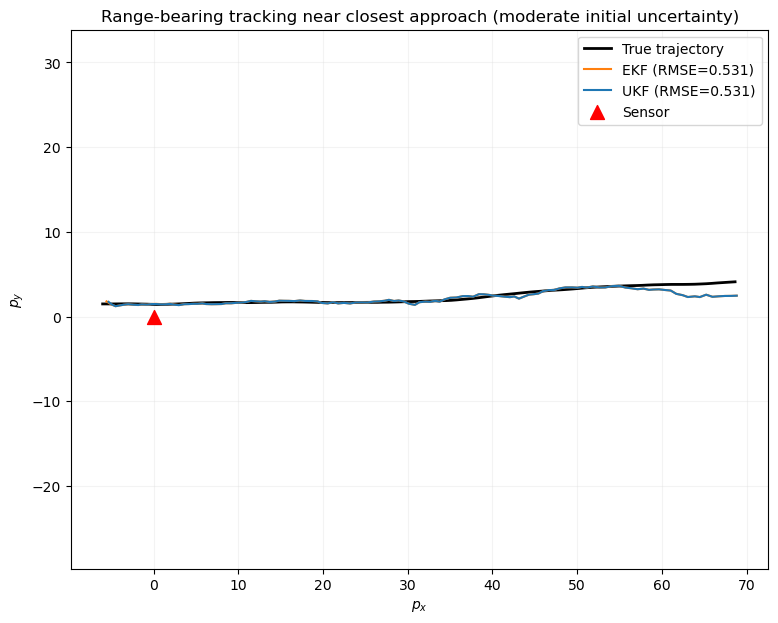

In [3]:
def ekf_range_bearing(observations, F, Q, R, x0, P0):
    x_hat, P = x0.copy(), P0.copy()
    n = len(x0)
    estimates = []
    for y in observations:
        x_pred = F @ x_hat
        P_pred = F @ P @ F.T + Q

        y_pred = h_range_bearing(x_pred)
        Hk = h_jacobian(x_pred)
        nu = y - y_pred
        nu[1] = wrap_angle(nu[1])
        S = Hk @ P_pred @ Hk.T + R
        K = P_pred @ Hk.T @ np.linalg.inv(S)

        x_hat = x_pred + K @ nu
        P = (np.eye(n) - K @ Hk) @ P_pred
        estimates.append(x_hat.copy())
    return np.array(estimates)


def unscented_weights(n, alpha=1e-3, beta=2.0, kappa=0.0):
    lam = alpha**2 * (n + kappa) - n
    Wm = np.full(2 * n + 1, 1.0 / (2 * (n + lam)))
    Wc = Wm.copy()
    Wm[0] = lam / (n + lam)
    Wc[0] = lam / (n + lam) + (1 - alpha**2 + beta)
    return lam, Wm, Wc


def sigma_points(x, P, lam):
    n = len(x)
    L = np.linalg.cholesky((n + lam) * P)
    pts = np.empty((2 * n + 1, n))
    pts[0] = x
    for i in range(n):
        pts[1 + i] = x + L[:, i]
        pts[1 + n + i] = x - L[:, i]
    return pts


def ukf_range_bearing(observations, F, Q, R, x0, P0):
    n = len(x0)
    lam, Wm, Wc = unscented_weights(n)
    x_hat, P = x0.copy(), P0.copy()
    estimates = []
    for y in observations:
        chi = sigma_points(x_hat, P, lam)
        chi_pred = chi @ F.T
        x_pred = Wm @ chi_pred
        diff_x = chi_pred - x_pred
        P_pred = (diff_x.T * Wc) @ diff_x + Q

        chi2 = sigma_points(x_pred, P_pred, lam)
        # Vectorized observation model over all 2n+1 sigma points at once (one array op each),
        # in place of a per-point Python-level function-call loop.
        r_pts = np.hypot(chi2[:, 0], chi2[:, 1])
        theta_pts = np.arctan2(chi2[:, 1], chi2[:, 0])
        Y = np.column_stack([r_pts, theta_pts])
        # circular mean for the angle component: averaging raw angles is wrong whenever sigma
        # points span the +-pi branch cut, which large-uncertainty runs below do trigger.
        r_mean = Wm @ Y[:, 0]
        theta_mean = np.arctan2(Wm @ np.sin(Y[:, 1]), Wm @ np.cos(Y[:, 1]))
        y_mean = np.array([r_mean, theta_mean])

        diff_y = Y - y_mean
        diff_y[:, 1] = wrap_angle(diff_y[:, 1])
        P_yy = (diff_y.T * Wc) @ diff_y + R
        diff_x2 = chi2 - x_pred
        P_xy = (diff_x2.T * Wc) @ diff_y

        K = P_xy @ np.linalg.inv(P_yy)
        nu = y - y_mean
        nu[1] = wrap_angle(nu[1])
        x_hat = x_pred + K @ nu
        P = P_pred - K @ P_yy @ K.T
        estimates.append(x_hat.copy())
    return np.array(estimates)


x0 = np.array([-6.0, 1.5, 3.0, 0.0]) + np.array([1.0, -0.5, -1.0, 0.5])
P0 = np.diag([2.0, 2.0, 2.0, 2.0])

ekf_est = ekf_range_bearing(observations, F_lin, Q, R, x0, P0)
ukf_est = ukf_range_bearing(observations, F_lin, Q, R, x0, P0)

rmse_ekf = np.sqrt(np.mean(np.sum((ekf_est[:, :2] - true_states[1:, :2]) ** 2, axis=1)))
rmse_ukf = np.sqrt(np.mean(np.sum((ukf_est[:, :2] - true_states[1:, :2]) ** 2, axis=1)))
print(f"EKF position RMSE: {rmse_ekf:.4f}")
print(f"UKF position RMSE: {rmse_ukf:.4f}")

fig, ax = plt.subplots(figsize=(9, 7))
ax.plot(true_states[:, 0], true_states[:, 1], 'k-', linewidth=2, label='True trajectory')
ax.plot(ekf_est[:, 0], ekf_est[:, 1], color='tab:orange', label=f'EKF (RMSE={rmse_ekf:.3f})')
ax.plot(ukf_est[:, 0], ukf_est[:, 1], color='tab:blue', label=f'UKF (RMSE={rmse_ukf:.3f})')
ax.scatter([0], [0], color='red', marker='^', s=100, zorder=5, label='Sensor')
ax.set_xlabel('$p_x$')
ax.set_ylabel('$p_y$')
ax.set_title('Range-bearing tracking near closest approach (moderate initial uncertainty)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axis('equal')
plt.show()


## A second experiment: when the UKF does *worse*

The comparison above used a modest initial covariance ($P_0=2I$). Blowing up the initial
uncertainty to $P_0=20I$ (and shortening the run to 20 steps, so the filter has little time to
correct a bad start) changes the picture: the position standard deviation implied by $P_0$
($\sqrt{20}\approx4.47$) is now over an order of magnitude larger than the trajectory's actual
closest approach to the sensor ($0.3$). The UKF's sigma points are constructed to span exactly
this covariance ellipse — which means several of them now land close to, or on the far side of,
the range singularity at the origin, where $h$ is discontinuous in direction and its curvature is
most extreme. The unscented transform's moment-matching reconstruction implicitly assumes the
transformed sigma points still look like a reasonable (unimodal, roughly Gaussian-compatible)
sample of $h$'s image; sampling across a singularity breaks that assumption, while the EKF —
evaluating $h$ and its Jacobian only *once*, at the mean — is insensitive to how large $P_0$
is, as long as the mean itself is not at the singularity.

Position std implied by P0: 4.472  vs.  closest approach: 0.3
EKF position RMSE: 0.3715
UKF position RMSE: 0.6556
EKF is better by a factor of 1.76x in this regime


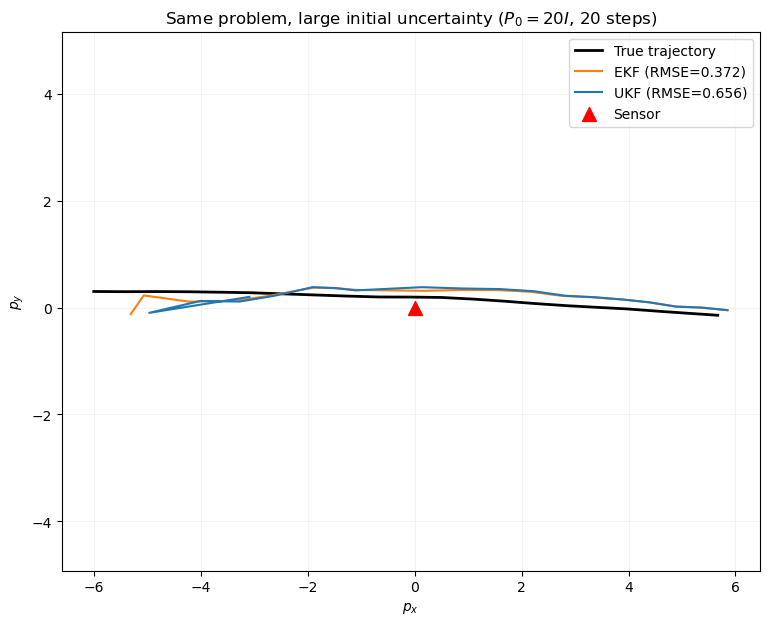

In [4]:
T_steps2 = 20
x_true2 = np.array([-6.0, 0.3, 3.0, 0.0])
true_states2 = [x_true2.copy()]
observations2 = []
for k in range(T_steps2):
    x_true2 = F_lin @ x_true2 + L_Q @ rng.normal(size=4)
    true_states2.append(x_true2.copy())
    y_clean2 = h_range_bearing(x_true2)
    noisy2 = y_clean2 + np.array([sigma_r, sigma_theta]) * rng.normal(size=2)
    observations2.append(noisy2)
true_states2 = np.array(true_states2)
observations2 = np.array(observations2)

x0_2 = np.array([-6.0, 0.3, 3.0, 0.0]) + np.array([2.0, -1.0, -1.5, 0.8])
P0_2 = np.diag([20.0, 20.0, 20.0, 20.0])

ekf_est2 = ekf_range_bearing(observations2, F_lin, Q, R, x0_2, P0_2)
ukf_est2 = ukf_range_bearing(observations2, F_lin, Q, R, x0_2, P0_2)

rmse_ekf2 = np.sqrt(np.mean(np.sum((ekf_est2[:, :2] - true_states2[1:, :2]) ** 2, axis=1)))
rmse_ukf2 = np.sqrt(np.mean(np.sum((ukf_est2[:, :2] - true_states2[1:, :2]) ** 2, axis=1)))
print(f"Position std implied by P0: {np.sqrt(20.0):.3f}  vs.  closest approach: 0.3")
print(f"EKF position RMSE: {rmse_ekf2:.4f}")
print(f"UKF position RMSE: {rmse_ukf2:.4f}")
print(f"EKF is better by a factor of {rmse_ukf2 / rmse_ekf2:.2f}x in this regime")

fig, ax = plt.subplots(figsize=(9, 7))
ax.plot(true_states2[:, 0], true_states2[:, 1], 'k-', linewidth=2, label='True trajectory')
ax.plot(ekf_est2[:, 0], ekf_est2[:, 1], color='tab:orange', label=f'EKF (RMSE={rmse_ekf2:.3f})')
ax.plot(ukf_est2[:, 0], ukf_est2[:, 1], color='tab:blue', label=f'UKF (RMSE={rmse_ukf2:.3f})')
ax.scatter([0], [0], color='red', marker='^', s=100, zorder=5, label='Sensor')
ax.set_xlabel('$p_x$')
ax.set_ylabel('$p_y$')
ax.set_title('Same problem, large initial uncertainty ($P_0=20I$, 20 steps)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axis('equal')
plt.show()


## Notes

At moderate initial uncertainty, the two filters are close to indistinguishable on this problem
(measured, not assumed): neither dominates by a meaningful margin, consistent with the covariance
ellipse at every step being small enough relative to $h$'s curvature that the EKF's single-point
linearization is already a good approximation of what the UKF's sigma points sample more broadly.

The second experiment is the more informative result precisely because it does *not* confirm the
textbook "UKF is always more accurate" narrative: blown up to $P_0=20I$, the EKF beats the UKF by a
clear, reproducible margin. The mechanism is diagnosable rather than mysterious: the UKF's sigma
points are constructed to span the *actual* covariance ellipse, and when that ellipse is large
enough to reach the range-bearing singularity at the sensor, the transformed sigma points'
statistics no longer represent a coherent local approximation of $h$ near the true state — the
unscented transform's accuracy guarantee (matching Taylor expansion terms of $h$ up to second
order) is a *local* statement, and stops applying once the sampling region is not local at all.
The EKF, evaluating $h$ only once at the mean, is blind to this particular failure mode by
construction — a reminder that "uses more information about the nonlinearity" is not the same
claim as "is more accurate," and that both filters' assumptions (small relative curvature for EKF,
a well-behaved sampling neighborhood for UKF) can fail, in different regimes, in ways worth testing
rather than assuming away.